In [21]:
# HR Analytics - Data Exploration and Wrangling
# Task 1: Load, clean, explore, and engineer the data

Shape of dataset: (1470, 31)

First five rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2



Column types (numeric vs categorical):


int64     23
object     8
Name: count, dtype: int64


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.92,9.14,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.49,403.51,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.91,1.02,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.89,20.33,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.06,1.11,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.73,1.10,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.93,4707.96,1009.0,2911.0,4919.0,8379.00,19999.0



Missing values per column:


Series([], dtype: int64)

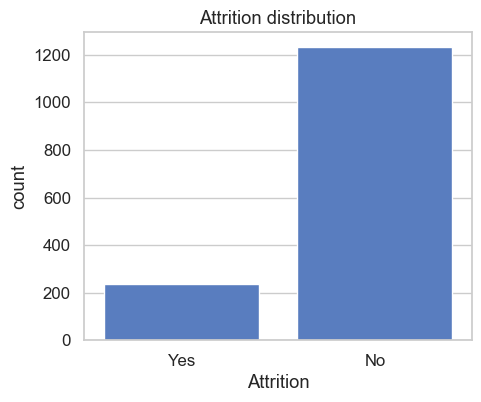

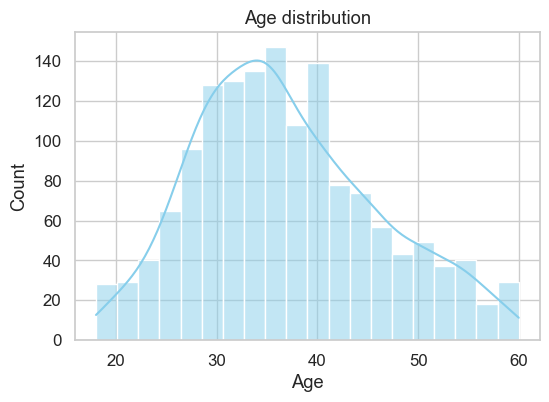

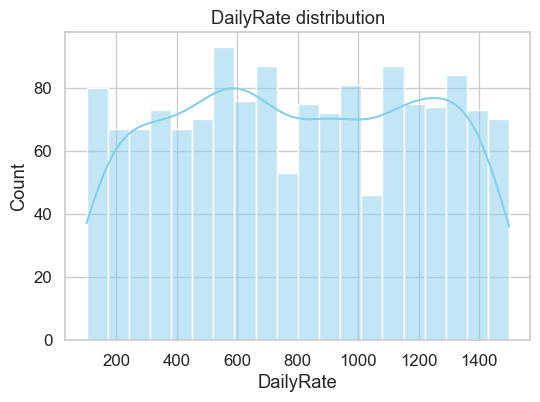

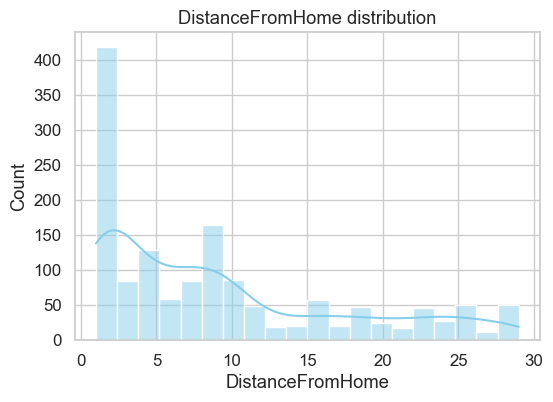

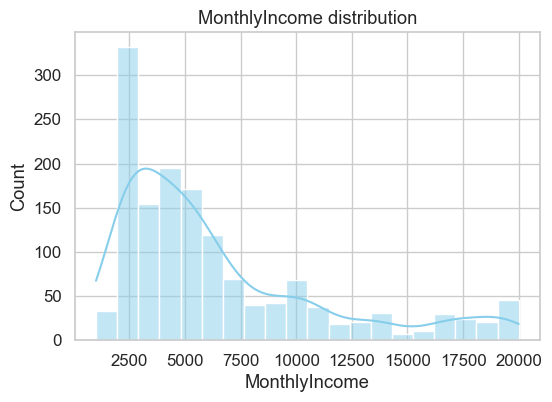

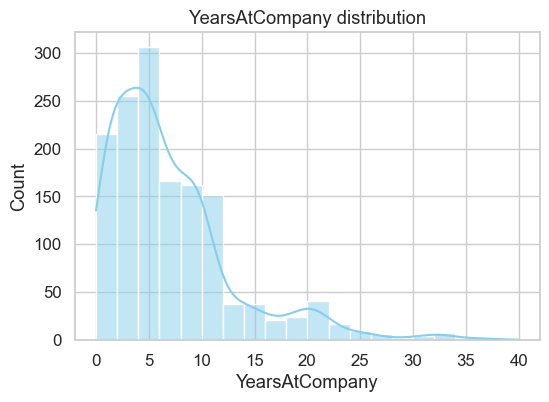

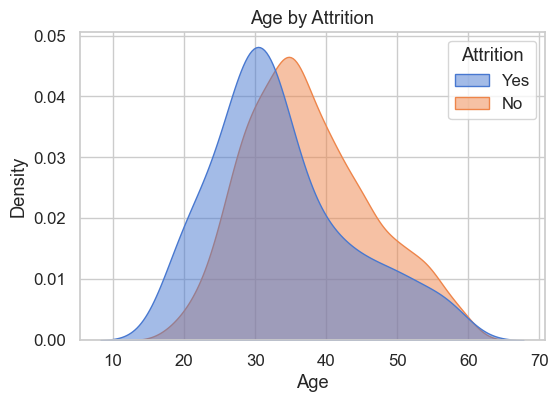

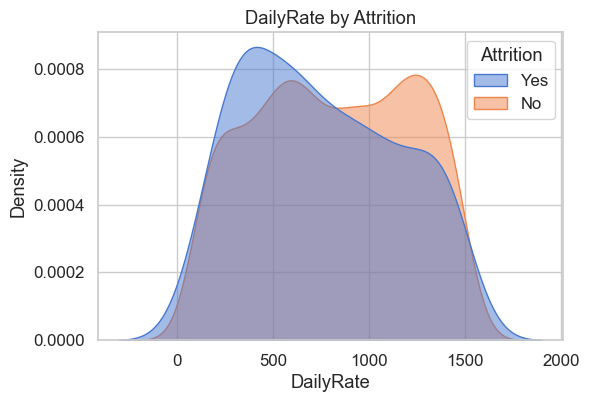

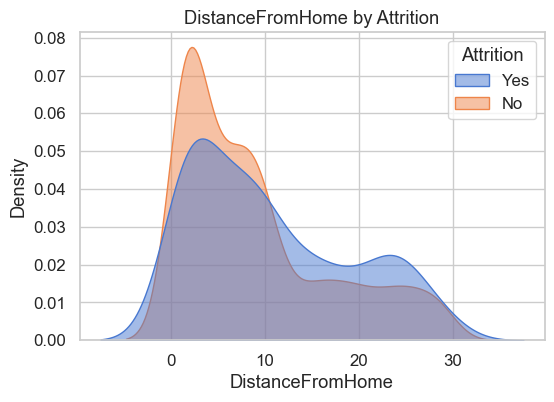

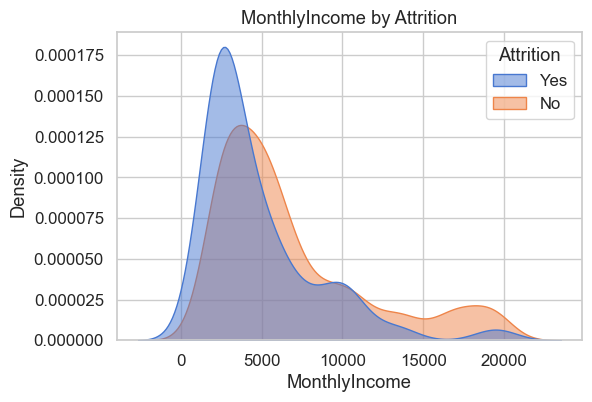

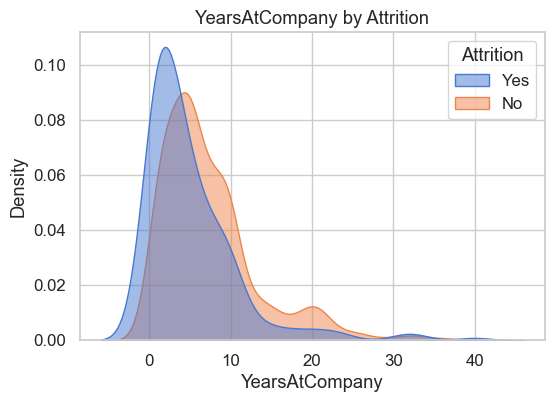

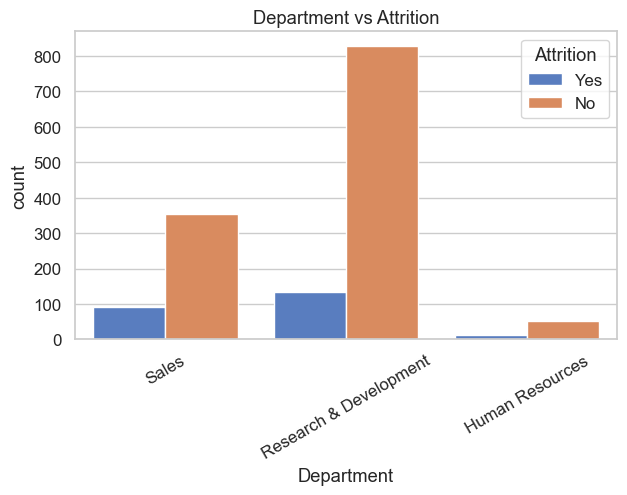

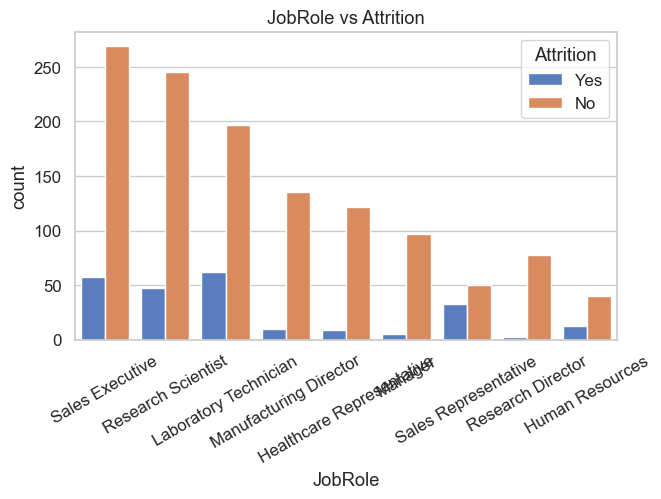

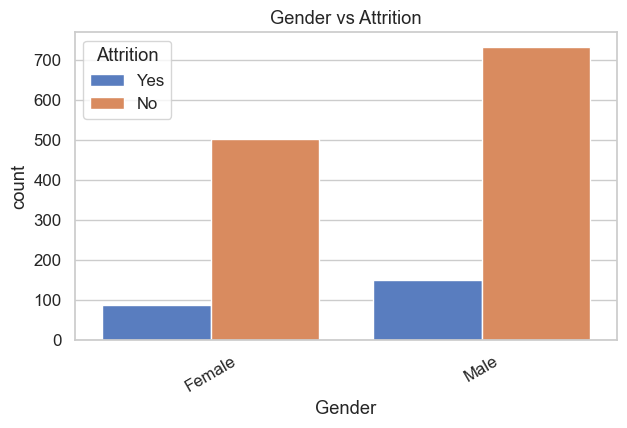

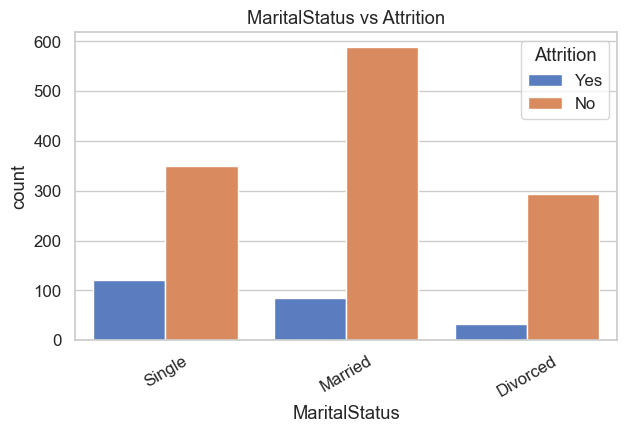

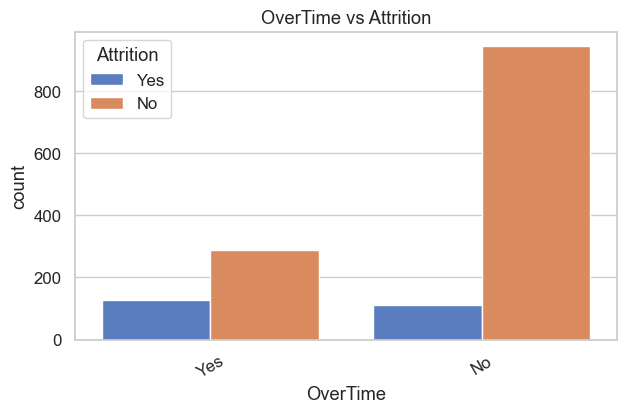

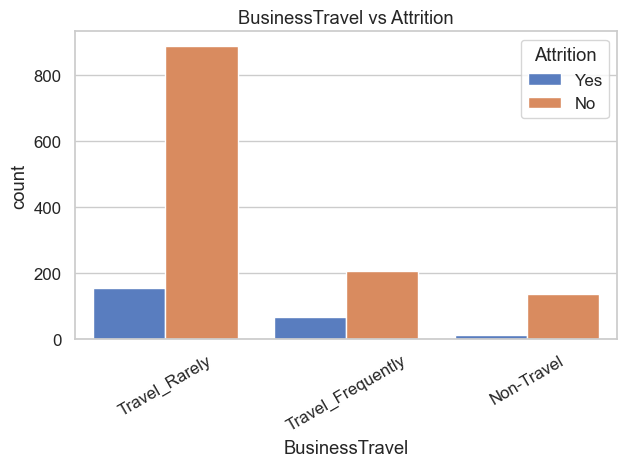

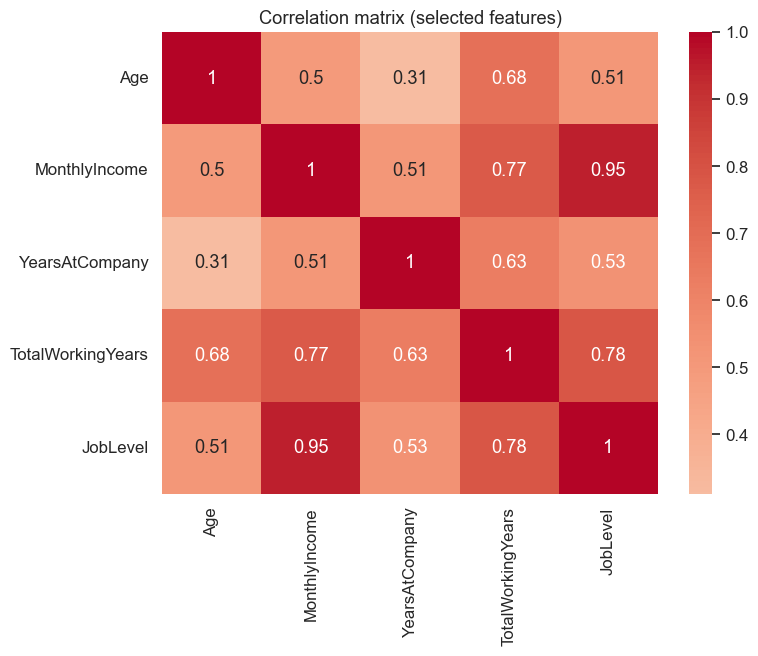

In [24]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# --- Load data ---
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# --- Drop irrelevant columns ---
df = df.drop(columns=["EmployeeNumber", "StandardHours", "Over18", "EmployeeCount"])

# --- Basic info ---
print("Shape of dataset:", df.shape)
print("\nFirst five rows:")
display(df.head())

print("\nColumn types (numeric vs categorical):")
display(df.dtypes.value_counts())

print("\nNumeric summary:")
display(df.describe().T.round(2))

# --- Missing values ---
missing = df.isna().sum()
print("\nMissing values per column:")
display(missing[missing > 0])

# --- Target distribution ---
plt.figure(figsize=(5,4))
sns.countplot(x="Attrition", data=df)
plt.title("Attrition distribution")
plt.show()

# --- Numeric distributions (selected) ---
num_features = ["Age", "DailyRate", "DistanceFromHome", "MonthlyIncome", "YearsAtCompany"]

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color="skyblue")
    plt.title(f"{col} distribution")
    plt.show()

# --- Numeric vs Attrition ---
for col in num_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue="Attrition", fill=True, common_norm=False, alpha=0.5)
    plt.title(f"{col} by Attrition")
    plt.show()

# --- Categorical vs Attrition ---
cat_features = ["Department", "JobRole", "Gender", "MaritalStatus", "OverTime", "BusinessTravel"]

for col in cat_features:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue="Attrition", data=df)
    plt.title(f"{col} vs Attrition")
    plt.xticks(rotation=30)
    plt.show()

# --- Correlation matrix (selected numeric features) ---
corr_features = ["Age", "MonthlyIncome", "YearsAtCompany", "TotalWorkingYears", "JobLevel"]
plt.figure(figsize=(8,6))
sns.heatmap(df[corr_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation matrix (selected features)")
plt.show()

# --- Feature preparation for modeling ---

# Define numeric & categorical columns
numeric_features = ["Age", "DailyRate", "DistanceFromHome", "MonthlyIncome", "YearsAtCompany",
                    "YearsInCurrentRole", "TotalWorkingYears", "JobLevel", "StockOptionLevel",
                    "TrainingTimesLastYear", "NumCompaniesWorked"]
categorical_features = ["JobRole", "Department", "EducationField", "MaritalStatus",
                        "Gender", "BusinessTravel", "OverTime"]

# Encode categorical variables
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[categorical_features])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_features))

# Combine numeric and encoded categorical features
df_prepared = pd.concat([df[numeric_features], encoded_df], axis=1)

# Optional: scale numeric features
scaler = StandardScaler()
df_prepared[numeric_features] = scaler.fit_transform(df_prepared[numeric_features])

joblib.dump(encoder, "../models/classification_encoder.joblib")


# --- Save processed dataset ---
df_prepared.to_csv("../data/processed_hr_dataset.csv", index=False)